# Maximum likelihood and maximum a posteriori — experiments

Companion notebook to the post. The experiments are numerical illustrations of
results stated there:

1. **Bernoulli MLE** — the log-likelihood is maximized at the observed frequency,
   and the estimate converges to the true parameter as the sample grows.
2. **Beta-Bernoulli posterior** — prior, likelihood, and posterior, with the MLE,
   the MAP estimate, and the posterior mean marked.
3. **Prior washout** — the posterior concentrates on the data as $n$ grows, so MAP
   approaches MLE.
4. **Gaussian-Gaussian shrinkage** — the MAP estimate is a precision-weighted
   average of the sample mean and the prior mean.
5. **Zero-count problem** — the categorical MLE assigns probability zero to unseen
   categories; a Dirichlet prior removes the zero.

Requires `numpy`, `matplotlib`, and `scipy`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import beta as beta_dist

# --- site theme -----------------------------------------------------------
BG, PANEL, LINE = "#0e1116", "#151a21", "#222a35"
FG, MUTED, ACCENT, ACCENT2 = "#d7dde6", "#8a94a3", "#4aa3ff", "#e0a458"
mpl.rcParams.update({
    "figure.facecolor": PANEL, "axes.facecolor": PANEL, "savefig.facecolor": PANEL,
    "axes.edgecolor": LINE, "axes.labelcolor": FG, "text.color": FG,
    "xtick.color": MUTED, "ytick.color": MUTED, "grid.color": LINE,
    "axes.grid": True, "grid.linewidth": 0.6, "grid.alpha": 0.7,
    "font.family": "monospace", "font.size": 11, "figure.dpi": 120,
    "axes.titlesize": 12, "legend.frameon": False, "legend.labelcolor": FG,
})

def style(ax):
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(LINE)
    return ax

rng = np.random.default_rng(0)

## 1. Bernoulli MLE

For $n$ trials with $k$ successes the log-likelihood is
$\ell(\theta)=k\log\theta+(n-k)\log(1-\theta)$, maximized at $\hat\theta=k/n$.

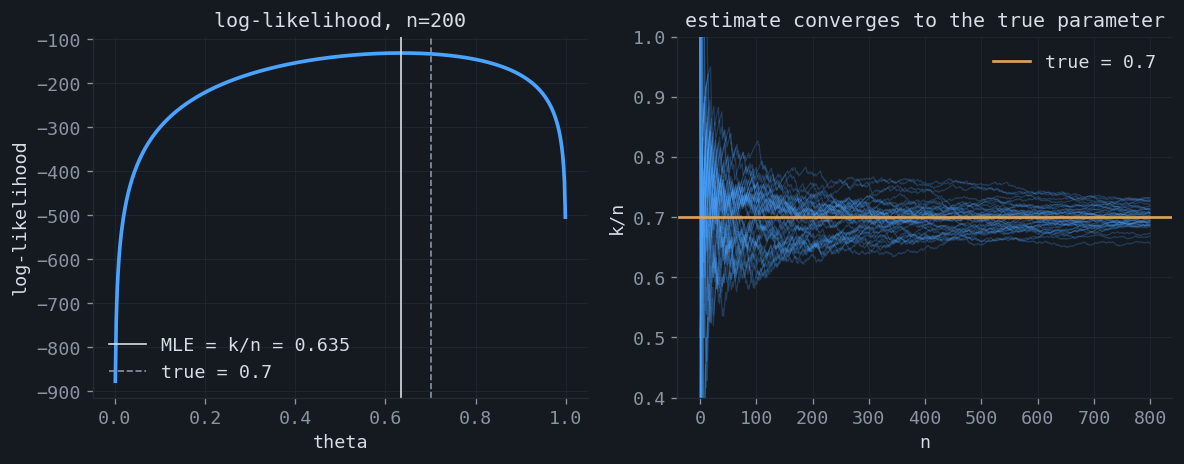

MLE = 0.635  (true 0.7)


In [2]:
true_p, n = 0.7, 200
flips = (rng.random(n) < true_p).astype(int)
k = flips.sum()

th = np.linspace(1e-3, 1-1e-3, 500)
ll = k*np.log(th) + (n-k)*np.log(1-th)
mle = k/n

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(th, ll, color=ACCENT, lw=2.2)
ax1.axvline(mle, color=FG, lw=1, label=f"MLE = k/n = {mle:.3f}")
ax1.axvline(true_p, color=MUTED, ls="--", lw=1, label=f"true = {true_p}")
ax1.set_xlabel("theta"); ax1.set_ylabel("log-likelihood")
ax1.set_title(f"log-likelihood, n={n}"); ax1.legend(); style(ax1)

for _ in range(40):
    seq = (rng.random(800) < true_p).astype(int)
    ax2.plot(np.cumsum(seq)/np.arange(1, 801), color=ACCENT, lw=0.7, alpha=0.25)
ax2.axhline(true_p, color=ACCENT2, lw=1.6, label=f"true = {true_p}")
ax2.set_xlabel("n"); ax2.set_ylabel("k/n"); ax2.set_ylim(0.4, 1.0)
ax2.set_title("estimate converges to the true parameter"); ax2.legend(); style(ax2)
plt.tight_layout(); plt.show()
print(f"MLE = {mle:.3f}  (true {true_p})")

## 2. Beta-Bernoulli posterior

With a $\text{Beta}(\alpha,\beta)$ prior and $k$ successes in $n$ trials, the posterior is
$\text{Beta}(k+\alpha,\,n-k+\beta)$. The MLE, MAP mode, and posterior mean are

$$ \hat\theta_{\text{MLE}}=\frac{k}{n},\quad
   \hat\theta_{\text{MAP}}=\frac{k+\alpha-1}{n+\alpha+\beta-2},\quad
   \mathbb{E}[\theta\mid D]=\frac{k+\alpha}{n+\alpha+\beta}. $$

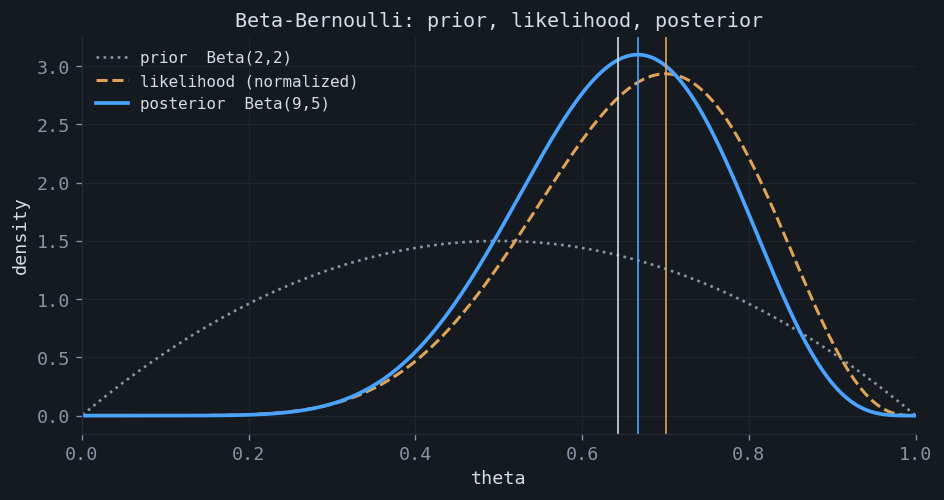

MLE = 0.700   MAP = 0.667   posterior mean = 0.643


In [3]:
k, n, a0, b0 = 7, 10, 2, 2
th = np.linspace(1e-3, 1-1e-3, 600)
prior = beta_dist.pdf(th, a0, b0)
lik = th**k * (1-th)**(n-k); lik /= np.trapezoid(lik, th)
post = beta_dist.pdf(th, k+a0, n-k+b0)

mle  = k/n
mode = (k+a0-1)/(n+a0+b0-2)
mean = (k+a0)/(n+a0+b0)

fig, ax = plt.subplots(figsize=(8, 4.3))
ax.plot(th, prior, color=MUTED, lw=1.6, ls=":", label="prior  Beta(2,2)")
ax.plot(th, lik, color=ACCENT2, lw=1.8, ls="--", label="likelihood (normalized)")
ax.plot(th, post, color=ACCENT, lw=2.2, label=f"posterior  Beta({k+a0},{n-k+b0})")
ax.axvline(mle, color=ACCENT2, lw=1); ax.axvline(mode, color=ACCENT, lw=1); ax.axvline(mean, color=FG, lw=1)
ax.set_xlabel("theta"); ax.set_ylabel("density"); ax.set_xlim(0, 1)
ax.set_title("Beta-Bernoulli: prior, likelihood, posterior"); ax.legend(loc="upper left", fontsize=9.5)
style(ax); plt.tight_layout(); plt.show()
print(f"MLE = {mle:.3f}   MAP = {mode:.3f}   posterior mean = {mean:.3f}")

## 3. Prior washout

The prior contributes a fixed term to the estimating equation, while the data term
grows with $n$. As $n$ increases the posterior concentrates on the data and MAP
approaches MLE. Here the prior $\text{Beta}(2,6)$ has mean $0.25$, disagreeing with the
true parameter $0.7$.

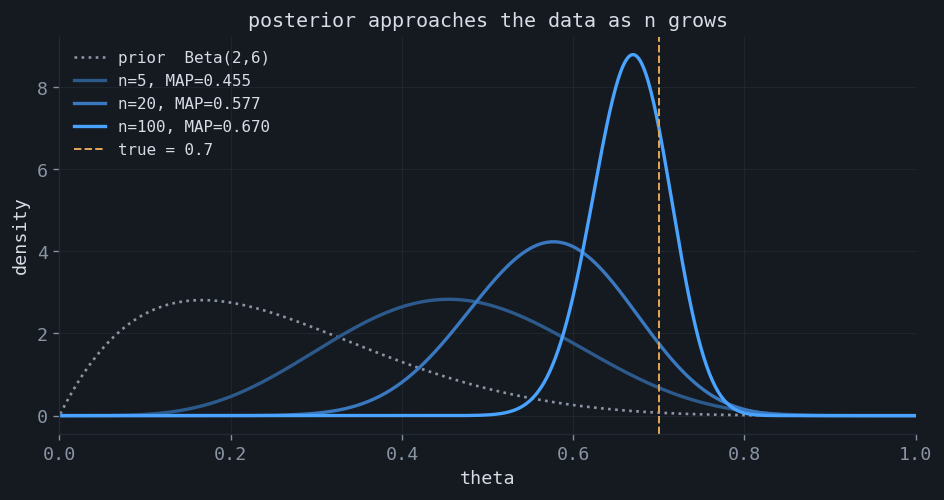

In [4]:
true_p, ap, bp = 0.7, 2, 6
fig, ax = plt.subplots(figsize=(8, 4.3))
ax.plot(th, beta_dist.pdf(th, ap, bp), color=MUTED, lw=1.6, ls=":", label="prior  Beta(2,6)")
for N, col in [(5, "#2d5a8c"), (20, "#3a78bf"), (100, ACCENT)]:
    kk = round(true_p*N)
    mode_N = (kk+ap-1)/(N+ap+bp-2)
    ax.plot(th, beta_dist.pdf(th, kk+ap, N-kk+bp), color=col, lw=2.0,
            label=f"n={N}, MAP={mode_N:.3f}")
ax.axvline(true_p, color=ACCENT2, lw=1.2, ls="--", label="true = 0.7")
ax.set_xlabel("theta"); ax.set_ylabel("density"); ax.set_xlim(0, 1)
ax.set_title("posterior approaches the data as n grows"); ax.legend(loc="upper left", fontsize=9.5)
style(ax); plt.tight_layout(); plt.show()

## 4. Gaussian-Gaussian shrinkage

For $x_i\sim N(\mu,\sigma^2)$ with known $\sigma^2$ and prior $\mu\sim N(\mu_0,\tau^2)$, the
posterior mode equals the posterior mean,

$$ \hat\mu_{\text{MAP}}=w\,\bar x+(1-w)\,\mu_0,\qquad
   w=\frac{n/\sigma^2}{n/\sigma^2+1/\tau^2}. $$

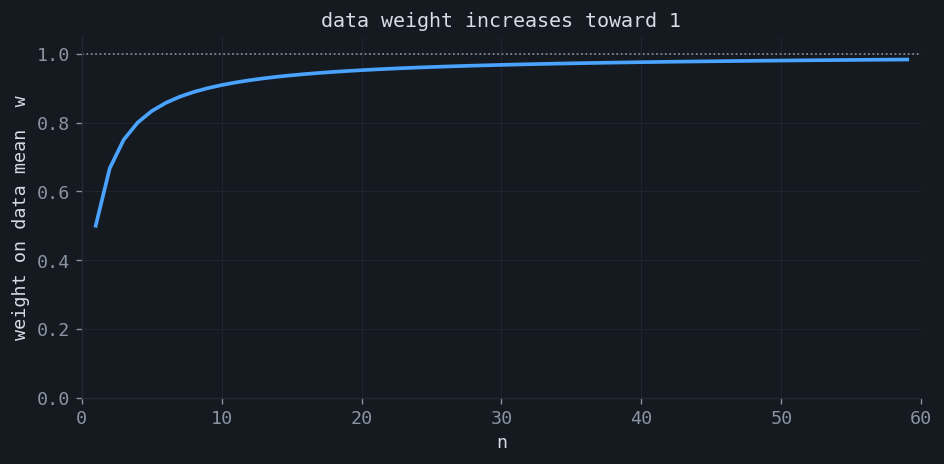

n= 1:  w = 0.500
n= 5:  w = 0.833
n=20:  w = 0.952


In [5]:
sigma2, tau2 = 1.0, 1.0
N = np.arange(1, 60)
w = (N/sigma2) / (N/sigma2 + 1/tau2)
fig, ax = plt.subplots(figsize=(8, 4.0))
ax.plot(N, w, color=ACCENT, lw=2.2); ax.axhline(1, color=MUTED, ls=":", lw=1)
ax.set_xlabel("n"); ax.set_ylabel("weight on data mean  w")
ax.set_ylim(0, 1.05); ax.set_xlim(0, 60)
ax.set_title("data weight increases toward 1"); style(ax)
plt.tight_layout(); plt.show()
for N0 in [1, 5, 20]:
    print(f"n={N0:2d}:  w = {(N0/sigma2)/(N0/sigma2+1/tau2):.3f}")

## 5. The zero-count problem

The categorical MLE is $\hat\pi_i=x_i/n$, so an unseen category receives probability
zero. A later observation in that category then has likelihood zero and infinite
negative log-likelihood. A $\text{Dirichlet}(\alpha)$ prior gives the MAP estimate
$\hat\pi_i=(x_i+\alpha_i-1)/(n+\sum_j(\alpha_j-1))$, which is positive for $\alpha_i>1$. The
symmetric choice $\alpha_i=2$ is add-one smoothing, $(x_i+1)/(n+m)$.

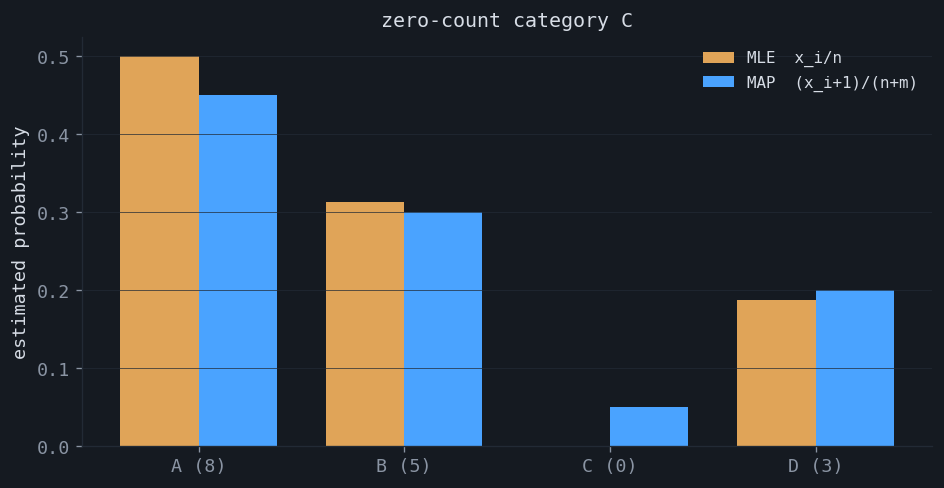

future observation in C:
  MLE: pi_C = 0.000  ->  log-likelihood = -inf
  MAP: pi_C = 0.050  ->  log-likelihood = -2.996


In [6]:
counts = np.array([8, 5, 0, 3]); labels = ["A", "B", "C", "D"]
N, K = counts.sum(), len(counts)
mle = counts / N
mapp = (counts + 1) / (N + K)        # Dirichlet(2) MAP = add-one

x = np.arange(K); width = 0.38
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.bar(x - width/2, mle, width, color=ACCENT2, label="MLE  x_i/n")
ax.bar(x + width/2, mapp, width, color=ACCENT, label="MAP  (x_i+1)/(n+m)")
ax.set_xticks(x); ax.set_xticklabels([f"{l} ({c})" for l, c in zip(labels, counts)])
ax.set_ylabel("estimated probability"); ax.set_title("zero-count category C")
ax.legend(loc="upper right", fontsize=9.5); style(ax); ax.grid(axis="x", alpha=0)
plt.tight_layout(); plt.show()

# log-likelihood of a future observation in category C under each estimate
print("future observation in C:")
print(f"  MLE: pi_C = {mle[2]:.3f}  ->  log-likelihood = {-np.inf if mle[2]==0 else np.log(mle[2]):.3f}")
print(f"  MAP: pi_C = {mapp[2]:.3f}  ->  log-likelihood = {np.log(mapp[2]):.3f}")

## Summary

- The MLE maximizes the log-likelihood; for the Bernoulli model it is the observed
  frequency $k/n$.
- The MAP estimate adds a prior, equivalent to a penalty $-\log p(\theta)$ on the
  log-likelihood.
- As $n$ grows the prior term becomes negligible and MAP approaches MLE; a flat prior
  makes them coincide.
- For categorical data the MLE assigns probability zero to unseen categories; a
  Dirichlet prior assigns positive probability and removes the resulting infinite
  loss.